In [99]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs
%matplotlib inline
import matplotlib.pyplot as plt

In [100]:
x,y=make_blobs(n_samples=1000,centers=3,n_features=2)

In [101]:
x

array([[10.45843613, -6.00787855],
       [-9.86842372, -7.18383468],
       [-9.6415932 , -6.75119464],
       ...,
       [ 8.08742368, -6.55182616],
       [-5.78694236,  0.3494082 ],
       [-9.73258376, -6.696443  ]], shape=(1000, 2))

In [102]:
y

array([2, 1, 1, 1, 1, 1, 2, 0, 1, 0, 1, 1, 0, 2, 1, 1, 2, 1, 0, 1, 2, 2,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 2, 2, 2, 0, 2, 1, 2, 2, 2, 2, 1, 0,
       1, 0, 2, 1, 1, 2, 0, 1, 1, 1, 1, 2, 2, 0, 0, 1, 1, 2, 1, 2, 2, 1,
       0, 2, 1, 1, 2, 2, 0, 0, 1, 0, 1, 2, 1, 2, 1, 2, 2, 1, 0, 1, 0, 0,
       0, 2, 0, 2, 2, 0, 1, 2, 1, 2, 2, 1, 1, 0, 0, 2, 0, 1, 0, 2, 1, 2,
       1, 0, 2, 2, 1, 1, 0, 1, 0, 2, 0, 0, 1, 0, 1, 2, 1, 2, 2, 2, 0, 1,
       1, 0, 1, 2, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 2, 0, 2, 0, 2, 1,
       0, 1, 0, 2, 0, 1, 2, 0, 2, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       1, 1, 0, 0, 1, 2, 1, 2, 0, 0, 2, 1, 1, 2, 0, 0, 1, 2, 0, 1, 2, 2,
       1, 1, 1, 0, 0, 0, 2, 2, 0, 1, 1, 0, 1, 0, 0, 2, 2, 1, 2, 1, 1, 0,
       1, 0, 2, 1, 0, 2, 0, 2, 0, 0, 2, 2, 2, 0, 0, 1, 2, 0, 0, 2, 0, 0,
       1, 2, 1, 0, 2, 2, 0, 0, 2, 2, 1, 0, 0, 1, 0, 1, 1, 2, 2, 2, 0, 0,
       1, 0, 1, 0, 0, 1, 2, 0, 2, 0, 0, 0, 2, 2, 2, 2, 1, 0, 0, 2, 0, 2,
       1, 1, 1, 1, 0, 1, 0, 1, 2, 0, 2, 0, 0, 2, 2,

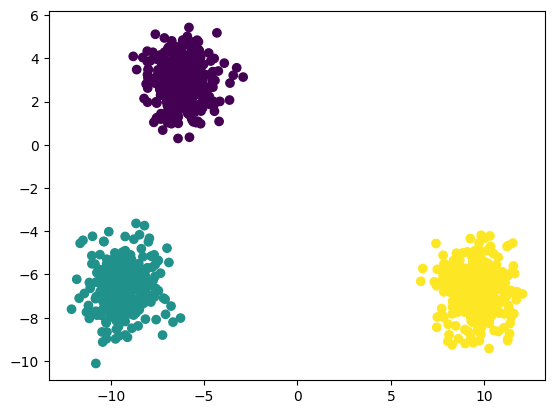

In [103]:
plt.scatter(x[:,0],x[:,1],c=y)

In [104]:
# stansardisation

In [105]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [106]:
from sklearn.model_selection import train_test_split

In [107]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [108]:
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [109]:
from sklearn.cluster import KMeans

In [110]:
# Elbow method to select K
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(x_train_scaled)
    wcss.append(kmeans.inertia_)


In [111]:
wcss

[1600.0000000000007,
 625.2228069317264,
 49.62587278355801,
 40.70873775838943,
 33.66564243574604,
 30.296348967130793,
 22.415929513931477,
 26.685127624444267,
 19.250315591829576,
 18.226958664534166]

AttributeError: module 'matplotlib.pyplot' has no attribute 'ylable'

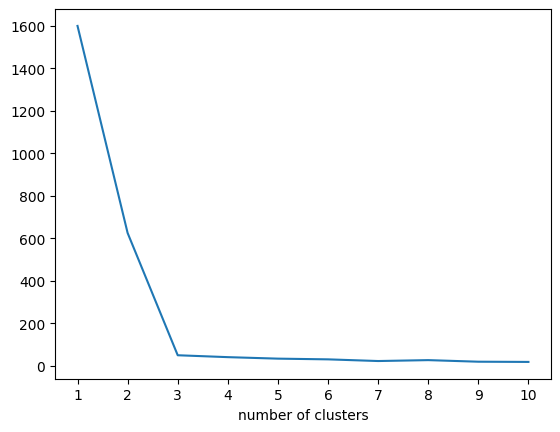

In [112]:
# plot ebow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("number of clusters")
plt.ylable("WCSS")
plt.show()

In [113]:
kmeans=KMeans(n_clusters=3,init="k-means++")

In [114]:
kmeans.fit_predict(x_train_scaled)

array([2, 1, 0, 1, 1, 0, 1, 1, 1, 2, 2, 1, 1, 1, 1, 0, 2, 1, 2, 1, 2, 0,
       0, 0, 1, 2, 1, 2, 0, 0, 0, 1, 2, 2, 0, 1, 0, 0, 2, 1, 2, 0, 0, 2,
       2, 0, 2, 0, 1, 2, 0, 2, 1, 2, 2, 1, 1, 0, 2, 2, 1, 2, 0, 2, 1, 0,
       1, 0, 1, 1, 2, 1, 0, 0, 1, 1, 0, 1, 0, 1, 2, 2, 0, 1, 1, 0, 0, 2,
       0, 0, 2, 0, 0, 0, 2, 0, 1, 2, 1, 2, 0, 0, 0, 2, 2, 2, 0, 0, 1, 0,
       1, 0, 0, 2, 2, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 2, 1, 0, 0, 1, 0, 0,
       2, 2, 0, 1, 1, 0, 0, 2, 1, 2, 2, 0, 2, 2, 2, 1, 1, 0, 0, 1, 0, 2,
       2, 2, 0, 2, 2, 1, 1, 2, 0, 1, 1, 2, 0, 0, 0, 1, 1, 2, 1, 2, 0, 1,
       0, 1, 2, 1, 1, 1, 0, 1, 2, 0, 2, 2, 1, 0, 1, 0, 0, 2, 0, 0, 0, 2,
       2, 0, 2, 2, 0, 1, 0, 2, 2, 0, 2, 0, 2, 0, 0, 2, 0, 2, 2, 2, 0, 1,
       1, 0, 2, 1, 2, 1, 2, 0, 2, 0, 0, 0, 0, 1, 0, 1, 2, 1, 0, 2, 2, 1,
       0, 2, 2, 2, 2, 2, 1, 1, 2, 2, 0, 1, 1, 0, 2, 1, 1, 0, 2, 0, 1, 0,
       1, 1, 2, 0, 1, 0, 0, 0, 1, 0, 0, 2, 0, 2, 1, 2, 2, 2, 2, 1, 0, 1,
       2, 2, 2, 1, 1, 1, 1, 2, 1, 1, 0, 0, 2, 0, 1,

In [115]:
y_pred=kmeans.predict(x_test_scaled)

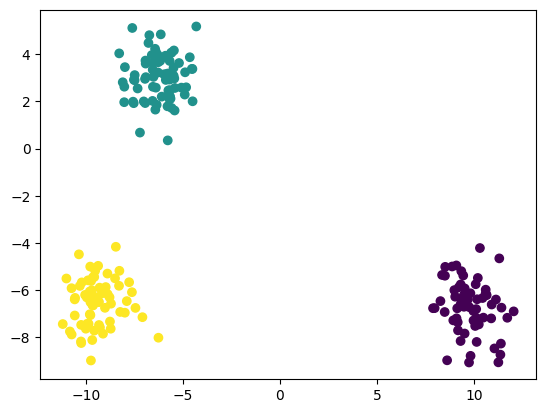

In [116]:
plt.scatter(x_test[:,0],x_test[:,1],c=y_pred)

In [ ]:
# validating k value ---> 

In [119]:
# knee locater
#Silhoutee scoring

In [120]:
!pip install kneed

In [121]:
from kneed import KneeLocator

In [122]:
kl=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

In [124]:
kl.elbow

np.int64(3)

In [125]:
# Silhoutee scaring

In [127]:
from sklearn.metrics import silhouette_score

In [ ]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(x_train_scaled)
    score=silhouette_score(x_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

In [129]:
silhouette_coefficients

[0.5956835418854249,
 0.85567542685583,
 0.7071142277069197,
 0.5563553031286761,
 0.5393535082540398,
 0.5016871962573665,
 0.3619387059757685,
 0.333465141611233,
 0.3484150859859625]

In [ ]:
# plot ebow curve
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("number of clusters")
plt.ylable("silhoutte coefficients")
plt.show()